# WTI Crude Oil Prices & Global Events (1970–2026)

An exploratory analysis of ~80 years of WTI crude oil prices against the geopolitical and
financial events that moved them. This notebook walks through the full workflow: loading and
cleaning data, visualizing the price history with events, ranking the biggest shocks, adjusting
for inflation, testing the oil–dollar and oil–gold relationships, and forecasting.

**Data sources:** WTI (`WTISPLC`), CPI (`CPIAUCSL`), Broad Dollar Index (`DTWEXBGS`) from
[FRED](https://fred.stlouisfed.org/); gold (`GC=F`) from Yahoo Finance. Full references are in
the `README.md`.

## 0. Setup
Imports, a one-time global chart style, and quiet logging for Prophet's backend.

In [1]:
%matplotlib inline
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

# Quiet Prophet's Stan backend logging
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
logging.getLogger("prophet").setLevel(logging.ERROR)

# Global chart style, set once for all figures
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 9

C:\Users\zheng\OneDrive\Desktop\Oil Price Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## 1. Load & clean the data

Standard pipeline for each source: read CSV → rename columns → parse dates → coerce numerics →
set a datetime index. Charts start at **1970** (dropping the flat price-controlled era while
keeping the 1973/1979 shocks).

In [2]:
# WTI monthly oil price
oil = pd.read_csv("oil_price.csv")
oil.columns = ["date", "price"]
oil["date"] = pd.to_datetime(oil["date"])
oil["price"] = pd.to_numeric(oil["price"], errors="coerce")
oil = oil.set_index("date").loc["1970":]
print("missing values:\n", oil.isna().sum())
oil.head()

missing values:
 price    0
dtype: int64


,price
date,
1970-01-01,3.35
1970-02-01,3.35
1970-03-01,3.35
1970-04-01,3.35
1970-05-01,3.35


**Inflation adjustment** — convert every month to 2026 dollars via `price × (CPI_latest / CPI_month)`.

In [3]:
cpi = pd.read_csv("cpi.csv")
cpi.columns = ["date", "cpi"]
cpi["date"] = pd.to_datetime(cpi["date"])
cpi["cpi"] = pd.to_numeric(cpi["cpi"], errors="coerce")
cpi["cpi"] = cpi["cpi"].ffill()          # fill the single missing month
cpi = cpi.set_index("date")

oil["cpi"] = cpi["cpi"]
base_cpi = cpi["cpi"].iloc[-1]           # use latest-month CPI as the base
oil["real_price"] = oil["price"] * base_cpi / oil["cpi"]

print("Top 5 by NOMINAL price:")
print(oil["price"].sort_values(ascending=False).head(5).round(1))
print("\nTop 5 by REAL price:")
print(oil["real_price"].sort_values(ascending=False).head(5).round(1))

Top 5 by NOMINAL price:
date
2008-06-01    133.9
2008-07-01    133.4
2008-05-01    125.4
2008-08-01    116.6
2022-06-01    114.8
Name: price, dtype: float64

Top 5 by REAL price:
date
2008-06-01    205.7
2008-07-01    203.5
2008-05-01    194.6
2008-08-01    178.1
2008-04-01    175.7
Name: real_price, dtype: float64


**Auxiliary series** — the dollar index (daily → monthly mean), gold (daily→monthly, stored in `gold.csv`), and the hand-curated events table.

In [4]:
# Dollar index: daily -> monthly mean
dollar = pd.read_csv("dollar_index.csv")
dollar.columns = ["date", "dollar"]
dollar["date"] = pd.to_datetime(dollar["date"])
dollar["dollar"] = pd.to_numeric(dollar["dollar"], errors="coerce")
dollar = dollar.set_index("date")
oil["dollar"] = dollar["dollar"].resample("MS").mean()

# Gold: already aggregated from daily to monthly means
gold = pd.read_csv("gold.csv")
gold["date"] = pd.to_datetime(gold["date"])
gold["gold"] = pd.to_numeric(gold["gold"], errors="coerce")
gold = gold.set_index("date")
oil["gold"] = gold["gold"]

# Events table
events = pd.read_csv("events.csv")
events["date"] = pd.to_datetime(events["date"])
events

,date,event
0,1973-10-01,Arab Oil Embargo
1,1979-01-01,Iranian Revolution
2,1980-09-01,Iran-Iraq War
3,1986-01-01,Saudi Price War / OPEC Collapse
4,1990-08-01,Gulf War (Iraq invades Kuwait)
5,1997-07-01,Asian Financial Crisis
6,2001-09-01,9/11 Attacks
7,2003-03-01,Iraq War
8,2008-07-01,Oil Peak / Global Financial Crisis
9,2011-01-01,Arab Spring


## 2. The big picture: 56 years of oil, annotated with events

Every major shock leaves a mark. Note the 1970s crises, the 2008 spike, the 2020 COVID collapse,
and the 2022 Ukraine surge.

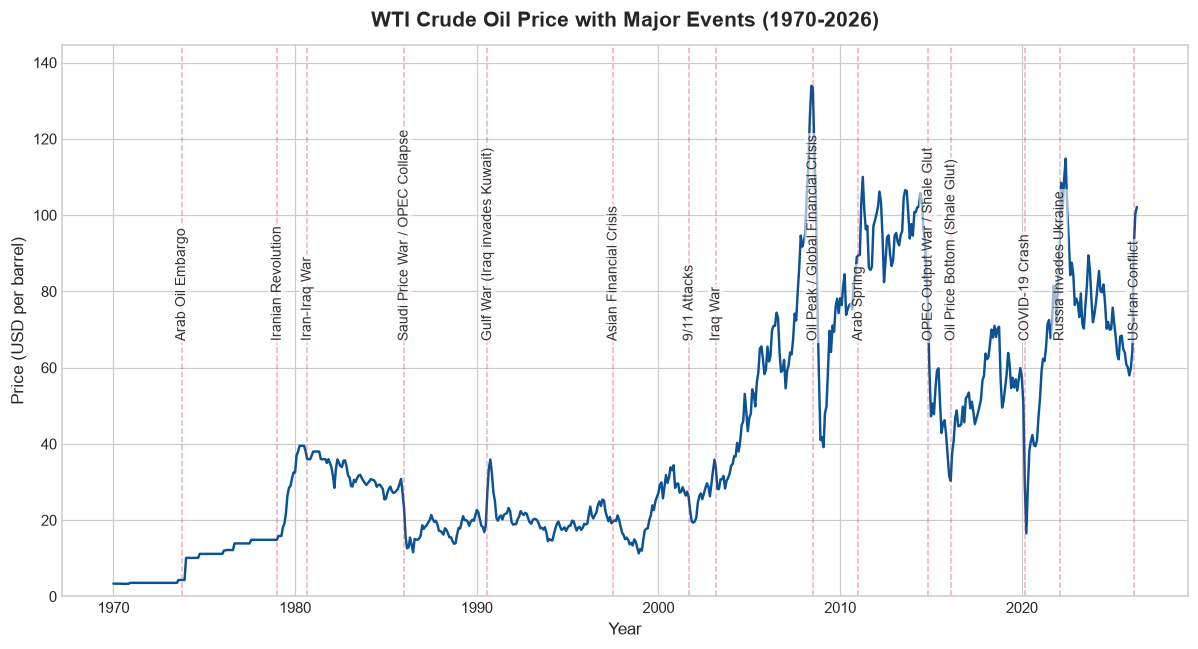

In [5]:
fig, ax = plt.subplots()
ax.plot(oil.index, oil["price"], color="#0b5394", linewidth=1.6)
ax.set_title("WTI Crude Oil Price with Major Events (1970-2026)", pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Price (USD per barrel)")

ymax = oil["price"].max()
ax.set_ylim(0, ymax * 1.08)
for _, row in events.iterrows():
    ax.axvline(row["date"], color="crimson", linestyle="--", alpha=0.35, linewidth=1)
    ax.text(row["date"], ymax * 0.50, row["event"],
            rotation=90, fontsize=9, color="#333333",
            ha="center", va="bottom",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6))
plt.tight_layout()

## 3. Biggest monthly moves — and automatic event matching

Rank months by absolute % change, then use `merge_asof` to auto-attach the nearest event within
a 180-day window. It matches 9 of the top 10 moves — the shocks really are event-driven.

In [6]:
oil["pct_change"] = oil["price"].pct_change() * 100
oil["abs_change"] = oil["pct_change"].abs()
biggest_moves = oil.sort_values("abs_change", ascending=False).head(10)

matched = pd.merge_asof(
    biggest_moves.sort_index().reset_index(),
    events.sort_values("date"),
    on="date", direction="nearest", tolerance=pd.Timedelta("180D"),
)
matched = matched.sort_values("abs_change", ascending=False)
matched[["date", "price", "pct_change", "event"]]

,date,price,pct_change,event
0,1974-01-01,10.110,134.570766,Arab Oil Embargo
7,2020-05-01,28.560,72.567976,COVID-19 Crash
3,1990-08-01,27.174,45.798905,Gulf War (Iraq invades Kuwait)
6,2020-04-01,16.550,-43.341321,COVID-19 Crash
5,2020-03-01,29.210,-42.204195,COVID-19 Crash
9,2026-03-01,91.380,41.652457,US-Iran Conflict
8,2020-06-01,38.310,34.138655,COVID-19 Crash
1,1986-02-01,15.442,-32.699935,Saudi Price War / OPEC Collapse
2,1986-08-01,15.092,30.384449,NaN
4,2008-12-01,41.020,-28.586351,Oil Peak / Global Financial Crisis


## 4. Event study: the 1990 Gulf War

Index the price to 100 at the event month and watch the ±6-month window. Oil jumped ~32% within
two months of Iraq's invasion of Kuwait.

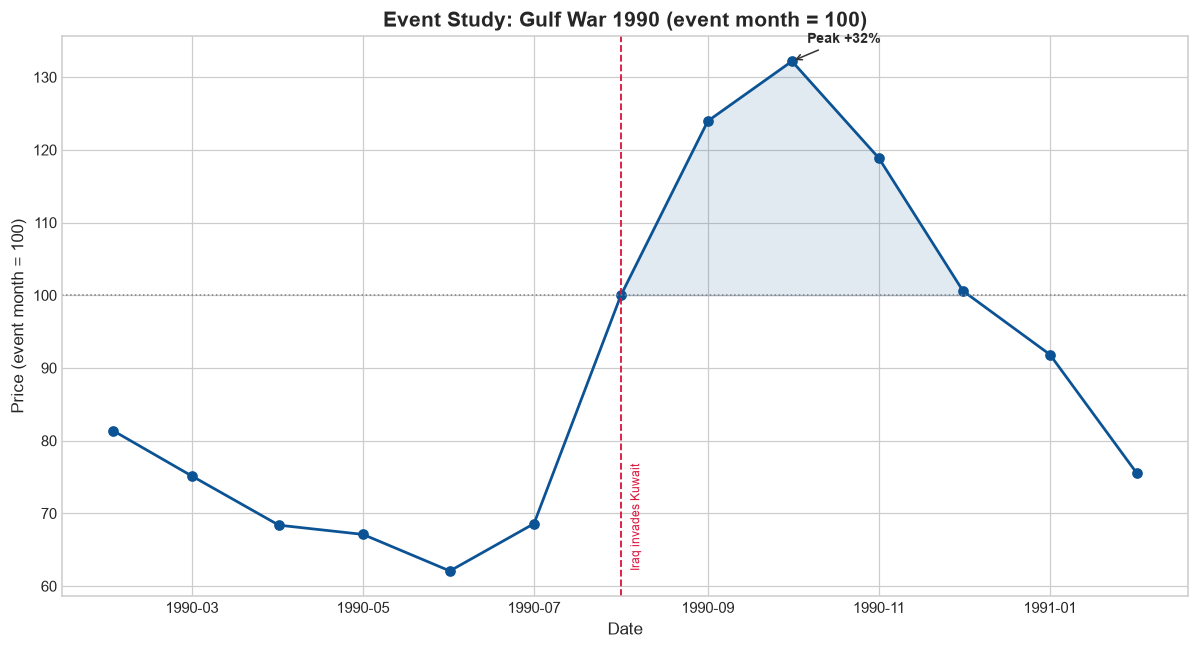

In [7]:
event_date = pd.Timestamp("1990-08-01")
window = oil.loc[event_date - pd.DateOffset(months=6):event_date + pd.DateOffset(months=6)].copy()
window["indexed"] = window["price"] / window.loc[event_date, "price"] * 100

fig, ax = plt.subplots()
ax.plot(window.index, window["indexed"], marker="o", color="#0b5394", linewidth=1.8)
ax.fill_between(window.index, 100, window["indexed"],
                where=window["indexed"] >= 100, color="#0b5394", alpha=0.12)
ax.axvline(event_date, color="crimson", linestyle="--", linewidth=1.2)
ax.axhline(100, color="gray", linestyle=":", linewidth=1)

peak_date = window["indexed"].idxmax()
peak_val = window["indexed"].max()
ax.annotate(f"Peak +{peak_val - 100:.0f}%", xy=(peak_date, peak_val),
            xytext=(10, 12), textcoords="offset points", fontsize=9, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#333333"))
ax.annotate("Iraq invades Kuwait", xy=(event_date, window["indexed"].min()),
            xytext=(6, 0), textcoords="offset points",
            rotation=90, va="bottom", fontsize=8, color="crimson")
ax.set_title("Event Study: Gulf War 1990 (event month = 100)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (event month = 100)")
plt.tight_layout()

## 5. Five crises on a common axis

Normalizing five shocks to their event month shows how differently oil reacted — a war spike
(1990) looks nothing like a demand collapse (2020).

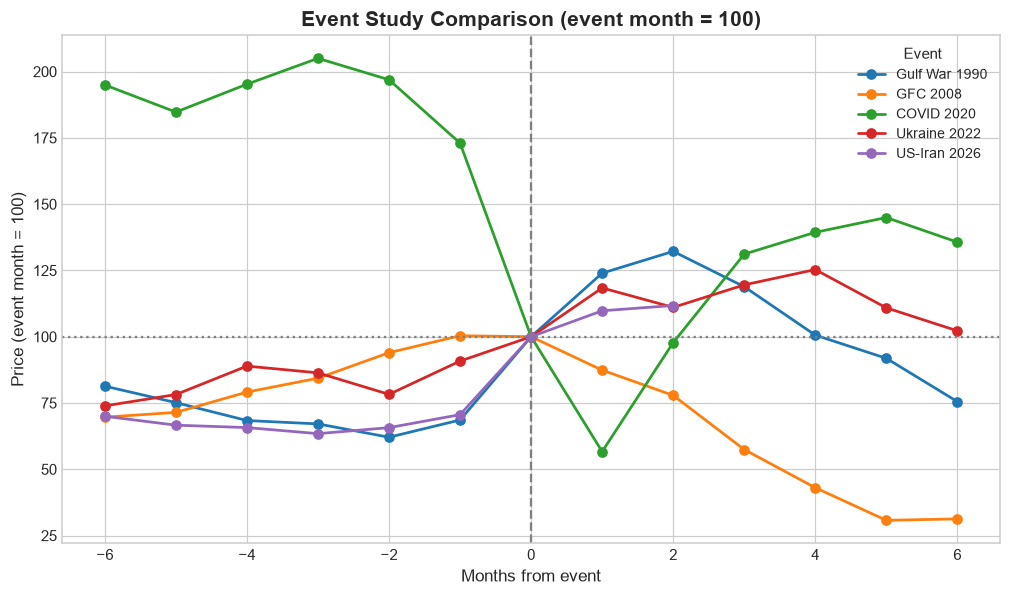

In [8]:
study_events = {
    "1990-08-01": "Gulf War 1990",
    "2008-07-01": "GFC 2008",
    "2020-03-01": "COVID 2020",
    "2022-02-01": "Ukraine 2022",
    "2026-03-01": "US-Iran 2026",
}
plt.figure()
for ev_str, name in study_events.items():
    ev = pd.Timestamp(ev_str)
    w = oil.loc[ev - pd.DateOffset(months=6):ev + pd.DateOffset(months=6)].copy()
    w["indexed"] = w["price"] / w.loc[ev, "price"] * 100
    months = (w.index.year - ev.year) * 12 + (w.index.month - ev.month)
    plt.plot(months, w["indexed"], marker="o", linewidth=1.8, label=name)

plt.axvline(0, color="gray", linestyle="--")
plt.axhline(100, color="gray", linestyle=":")
plt.title("Event Study Comparison (event month = 100)")
plt.xlabel("Months from event")
plt.ylabel("Price (event month = 100)")
plt.legend(title="Event")

## 6. Real vs nominal: the most expensive oil was 2008, not the 1970s

Once inflation is removed, June 2008 is the all-time high (~\$206 in 2026 dollars). Nominal
prices badly mislead across decades.

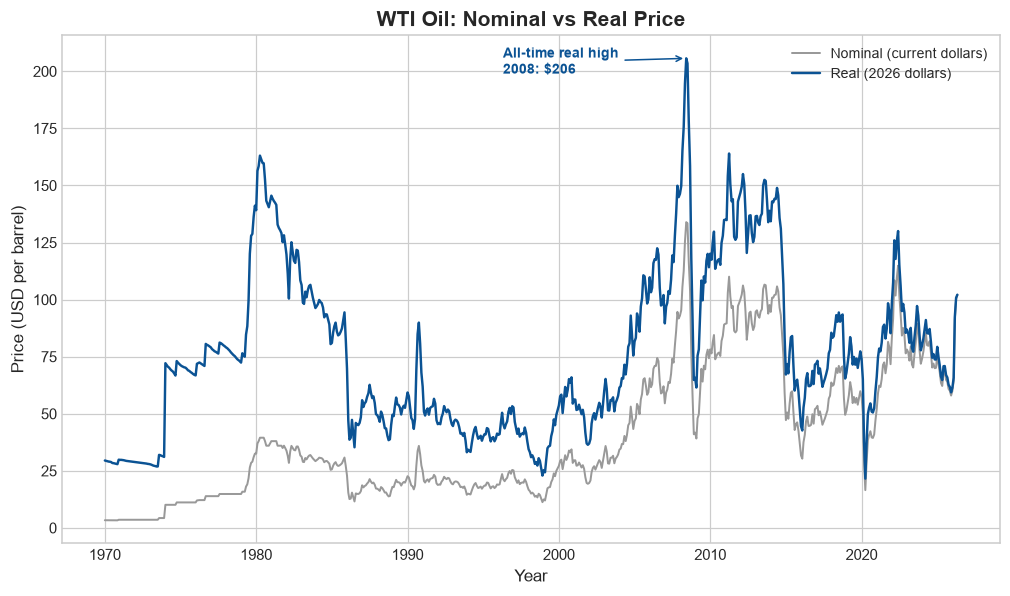

In [9]:
fig, ax = plt.subplots()
ax.plot(oil.index, oil["price"], color="#999999", linewidth=1.3, label="Nominal (current dollars)")
ax.plot(oil.index, oil["real_price"], color="#0b5394", linewidth=1.6, label="Real (2026 dollars)")

rp_date = oil["real_price"].idxmax()
rp_val = oil["real_price"].max()
ax.annotate(f"All-time real high\n{rp_date.year}: ${rp_val:.0f}",
            xy=(rp_date, rp_val), xytext=(-120, -10), textcoords="offset points",
            fontsize=9, fontweight="bold", color="#0b5394",
            arrowprops=dict(arrowstyle="->", color="#0b5394"))
ax.set_title("WTI Oil: Nominal vs Real Price")
ax.set_xlabel("Year")
ax.set_ylabel("Price (USD per barrel)")
ax.legend()

## 7. Oil vs the US dollar

Oil is priced in dollars, so a stronger dollar should push oil down. The correlation confirms a
moderate inverse link — stronger on levels, weaker (and more honest) on monthly returns.

Correlation (levels): -0.476
Correlation (monthly % change): -0.393


Text(0.5, 1.0, 'Oil vs US Dollar Index (2006-2026, r=-0.48)')

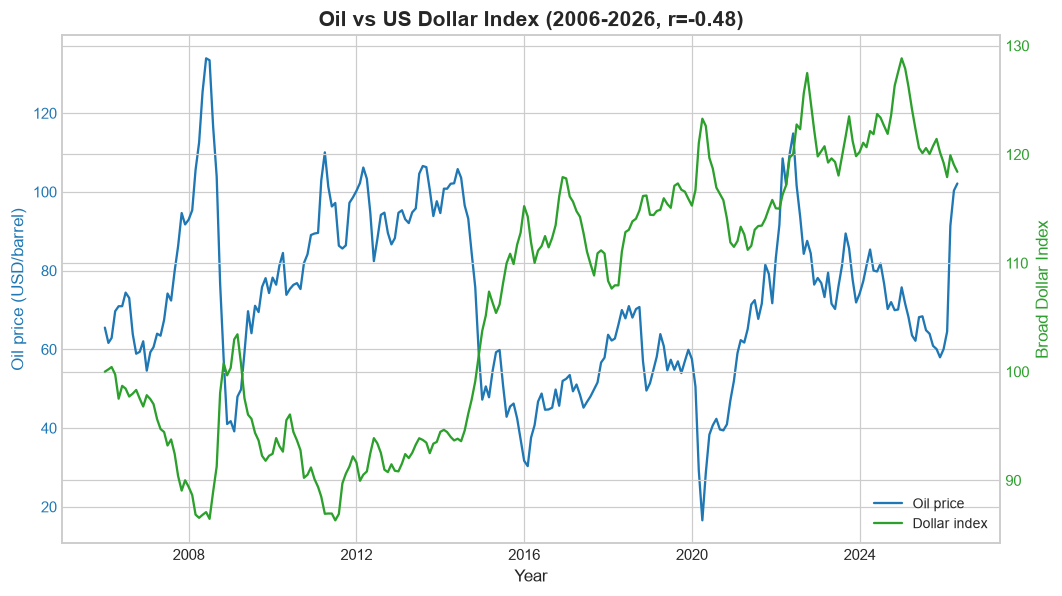

In [10]:
corr = oil["price"].corr(oil["dollar"])
corr_pct = oil["price"].pct_change().corr(oil["dollar"].pct_change())
print("Correlation (levels):", round(corr, 3))
print("Correlation (monthly % change):", round(corr_pct, 3))

d = oil.loc["2006":]
fig, ax1 = plt.subplots()
ax1.plot(d.index, d["price"], color="tab:blue", label="Oil price")
ax1.set_xlabel("Year")
ax1.set_ylabel("Oil price (USD/barrel)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(d.index, d["dollar"], color="tab:green", label="Dollar index")
ax2.set_ylabel("Broad Dollar Index", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")

lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [ln.get_label() for ln in lines], loc="lower right")
ax1.set_title(f"Oil vs US Dollar Index (2006-2026, r={corr:.2f})")

## 8. The relationship isn't stable — rolling correlation

A 36-month rolling correlation shows the oil–dollar link swings widely and even **flipped positive
in 2023–24** (Fed hikes + Ukraine pushed both up together). A single headline number hides this.

Text(0, 0.5, 'Correlation')

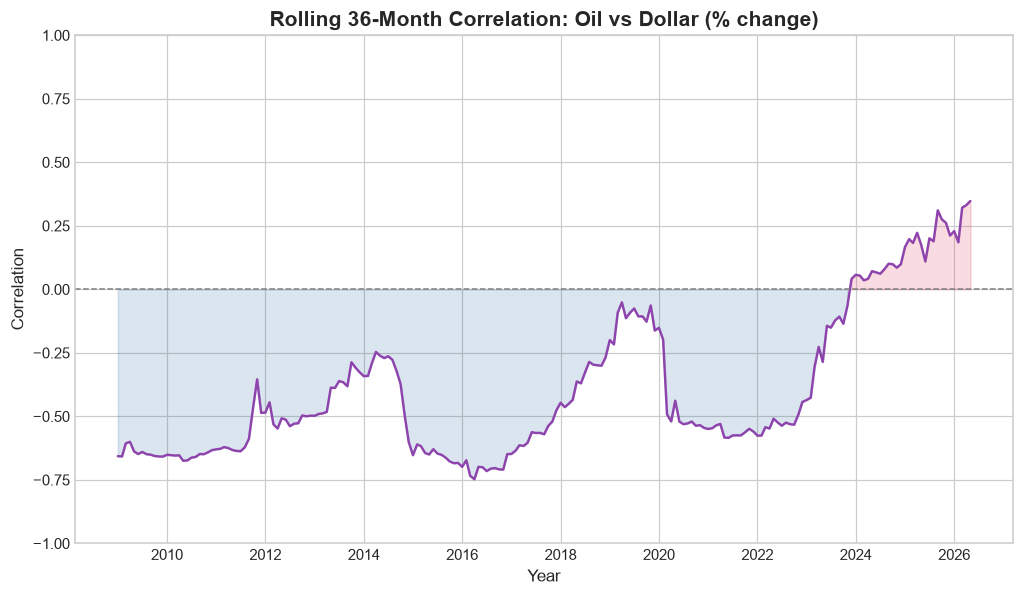

In [11]:
oil["roll_corr"] = oil["price"].pct_change().rolling(36).corr(oil["dollar"].pct_change())

fig, ax = plt.subplots()
ax.plot(oil.index, oil["roll_corr"], color="#8e44ad", linewidth=1.6)
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.fill_between(oil.index, 0, oil["roll_corr"], where=oil["roll_corr"] >= 0, color="crimson", alpha=0.15)
ax.fill_between(oil.index, 0, oil["roll_corr"], where=oil["roll_corr"] < 0, color="#0b5394", alpha=0.15)
ax.set_ylim(-1, 1)
ax.set_title("Rolling 36-Month Correlation: Oil vs Dollar (% change)")
ax.set_xlabel("Year")
ax.set_ylabel("Correlation")

## 9. Regression: strong direction, weak explanatory power

Regressing oil returns on dollar returns: a 1% dollar move maps to a ~3% opposite oil move, but
**R² is only ~0.15** — the dollar sets direction, not magnitude.

oil% = -3.16 * dollar% + (1.00)   R² = 0.154


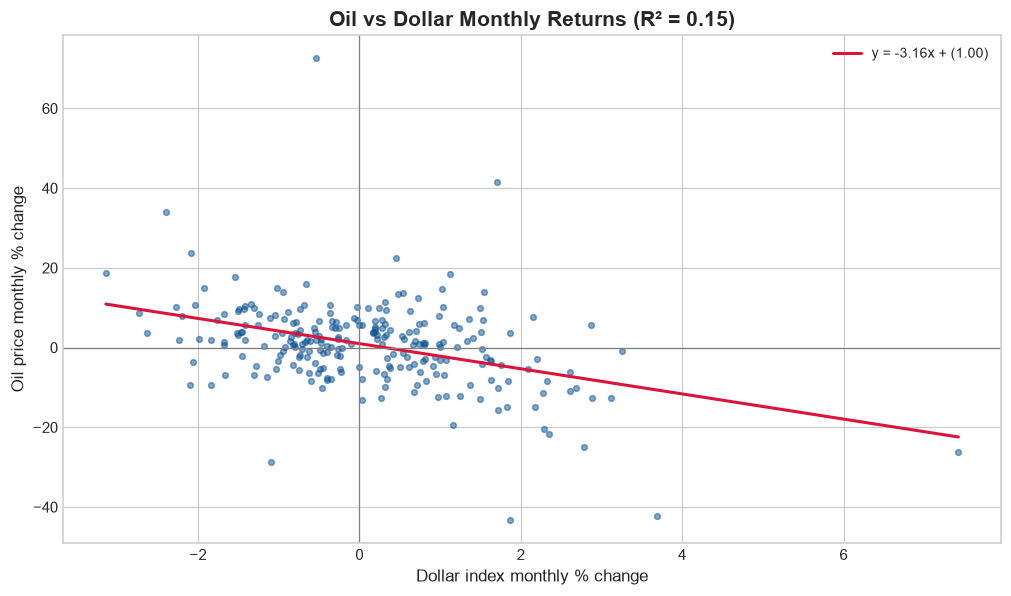

In [12]:
reg = oil[["price", "dollar"]].pct_change().dropna() * 100
x = reg["dollar"]
y = reg["price"]
slope, intercept = np.polyfit(x, y, 1)
r2 = x.corr(y) ** 2
print(f"oil% = {slope:.2f} * dollar% + ({intercept:.2f})   R² = {r2:.3f}")

fig, ax = plt.subplots()
ax.scatter(x, y, s=14, alpha=0.5, color="#0b5394")
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, slope * xs + intercept, color="crimson", linewidth=2, label=f"y = {slope:.2f}x + ({intercept:.2f})")
ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_title(f"Oil vs Dollar Monthly Returns (R² = {r2:.2f})")
ax.set_xlabel("Dollar index monthly % change")
ax.set_ylabel("Oil price monthly % change")
ax.legend()

## 10. Oil vs gold: a textbook spurious correlation

On levels, oil and gold look linked (r ≈ +0.39). But on monthly returns the correlation is
**~0** — the apparent link is just a shared upward trend. Always confirm a level correlation on
returns before believing it.

Correlation (levels): 0.391
Correlation (monthly % change): 0.048


Text(0.5, 1.0, 'Oil vs Gold (level r=0.39, but return r=0.05)')

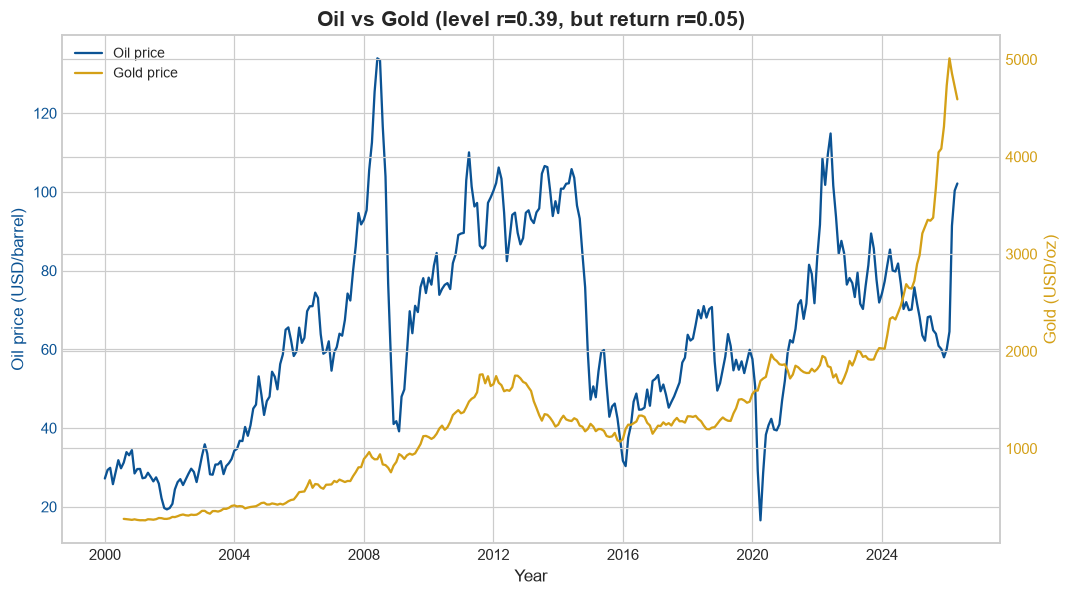

In [13]:
corr_gold = oil["price"].corr(oil["gold"])
corr_gold_pct = oil["price"].pct_change().corr(oil["gold"].pct_change())
print("Correlation (levels):", round(corr_gold, 3))
print("Correlation (monthly % change):", round(corr_gold_pct, 3))

g = oil.loc["2000":]
fig, ax1 = plt.subplots()
ax1.plot(g.index, g["price"], color="#0b5394", label="Oil price")
ax1.set_xlabel("Year")
ax1.set_ylabel("Oil price (USD/barrel)", color="#0b5394")
ax1.tick_params(axis="y", labelcolor="#0b5394")

ax2 = ax1.twinx()
ax2.plot(g.index, g["gold"], color="#d4a017", label="Gold price")
ax2.set_ylabel("Gold (USD/oz)", color="#d4a017")
ax2.tick_params(axis="y", labelcolor="#d4a017")

lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [ln.get_label() for ln in lines], loc="upper left")
ax1.set_title(f"Oil vs Gold (level r={corr_gold:.2f}, but return r={corr_gold_pct:.2f})")

## 11. Forecasting: ARIMA (with a Prophet comparison)

An `ARIMA(1,1,1)` forecast is an almost flat line — oil behaves like a random walk, so the point
forecast isn't the story; the **widening confidence interval** is. Prophet is wired in for
comparison but guarded with a `try/except` (its Stan backend fails to load on this Windows setup).

ARIMA 12-month forecast (USD/barrel):
2026-06-01    102.6
2026-07-01    102.8
2026-08-01    102.8
2026-09-01    102.8
2026-10-01    102.8
2026-11-01    102.8
2026-12-01    102.8
2027-01-01    102.8
2027-02-01    102.8
2027-03-01    102.8
2027-04-01    102.8
2027-05-01    102.8
Freq: MS, Name: predicted_mean, dtype: float64


15:53:17 - cmdstanpy - INFO - Chain [1] start processing


15:53:17 - cmdstanpy - INFO - Chain [1] done processing


15:53:17 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


15:53:17 - cmdstanpy - INFO - Chain [1] start processing


15:53:17 - cmdstanpy - INFO - Chain [1] done processing


15:53:17 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


Prophet skipped (backend unavailable): RuntimeError


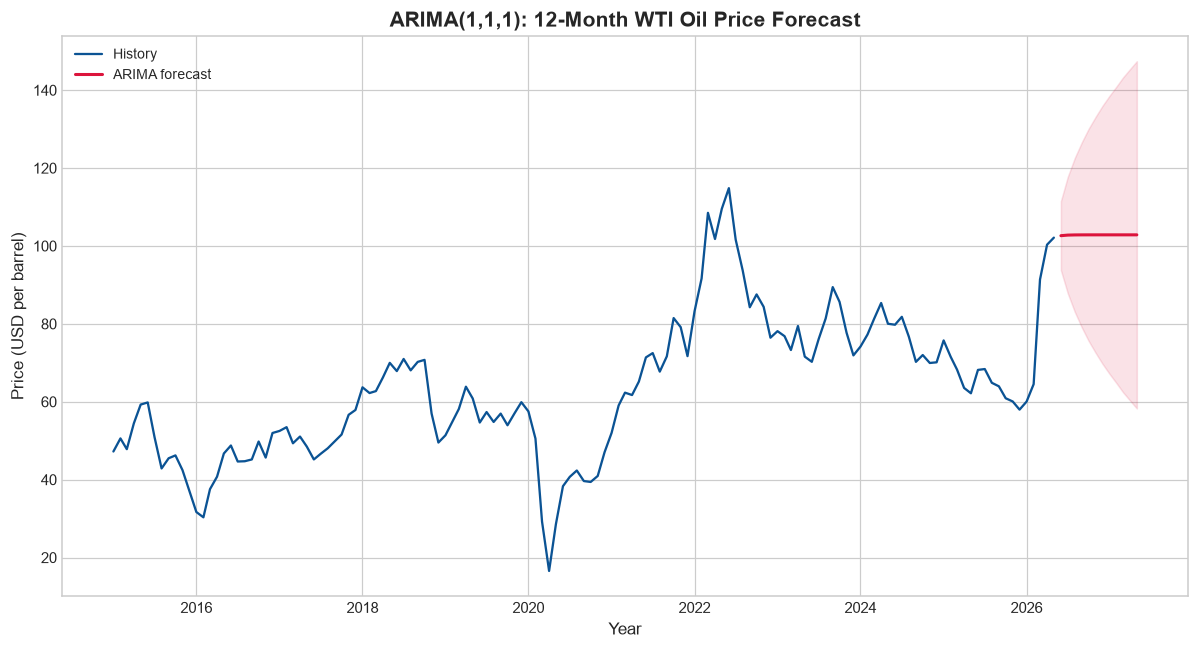

In [14]:
oil_ts = oil.loc["1986":, "price"].asfreq("MS")
arima_fit = ARIMA(oil_ts, order=(1, 1, 1)).fit()
fc = arima_fit.get_forecast(steps=12)
mean_fc = fc.predicted_mean
ci = fc.conf_int()
print("ARIMA 12-month forecast (USD/barrel):")
print(mean_fc.round(1))

prophet_future = None
try:
    prophet_df = oil_ts.reset_index()
    prophet_df.columns = ["ds", "y"]
    m = Prophet(interval_width=0.95)
    m.fit(prophet_df)
    future = m.make_future_dataframe(periods=12, freq="MS")
    prophet_fc = m.predict(future).set_index("ds")
    prophet_future = prophet_fc.loc[mean_fc.index]
except Exception as e:
    print("Prophet skipped (backend unavailable):", type(e).__name__)

fig, ax = plt.subplots()
recent = oil_ts.loc["2015":]
ax.plot(recent.index, recent, color="#0b5394", label="History")
ax.plot(mean_fc.index, mean_fc, color="crimson", linewidth=2, label="ARIMA forecast")
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color="crimson", alpha=0.12)
if prophet_future is not None:
    ax.plot(prophet_future.index, prophet_future["yhat"], color="#2e8b57", linewidth=2, label="Prophet forecast")
    ax.fill_between(prophet_future.index, prophet_future["yhat_lower"], prophet_future["yhat_upper"],
                    color="#2e8b57", alpha=0.12)
    ax.set_title("Oil Price 12-Month Forecast: ARIMA vs Prophet")
else:
    ax.set_title("ARIMA(1,1,1): 12-Month WTI Oil Price Forecast")
ax.set_xlabel("Year")
ax.set_ylabel("Price (USD per barrel)")
ax.legend(loc="upper left")
plt.tight_layout()

## 12. Conclusions

1. **Shocks are event-driven** — 9 of the 10 biggest monthly moves map to a known geopolitical or
   financial event.
2. **2008 was the most expensive oil ever, in real terms** (~\$206) — nominal prices mislead
   across decades.
3. **Oil and the dollar are moderately inversely linked** (r ≈ −0.4), strong in direction but
   explaining only ~15% of monthly variance — and the link is unstable, even flipping positive in
   2023–24.
4. **Oil and gold are not really correlated** month-to-month (~0); the apparent link is a shared
   trend — a clean example of spurious correlation.
5. **Short-horizon oil prices are effectively unpredictable** — ARIMA returns a flat forecast with
   fast-widening error bars; the honest deliverable is *uncertainty*, not a false-precision number.

*See `README.md` for full data references and methodology notes.*